<a href="https://colab.research.google.com/github/JyRaGa/CS303-Machine-Learning_Coursework/blob/main/lab2_LR%2BSVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS303 Machine Learning Lab
## Experiment 2: Problem Formulation, Dataset Inspection and Baseline Modelling
### (24/CS/232)

**1. Problem Formulation & Naive Prediction**

* **Problem Type:** We need to predict if a passenger survived or not. Since survival is a discrete category (0 or 1), this is a classification problem.
* **Naive Prediction:** Most people died on the Titanic. If we just create a dumb baseline model that guesses 0 (did not survive) for every passenger, we should get around 60% accuracy purely based on the dataset's class distribution.

**2. Loading the Dataset**

In [1]:
# importing pandas for data manipulation
import pandas as pd
# importing numpy for math operations
import numpy as np
# importing matplotlib for plotting graphs
import matplotlib.pyplot as plt
# importing seaborn for better looking charts
import seaborn as sns

# reading the csv file into a dataframe
df = pd.read_csv('Titanic-Dataset.csv')

# printing the number of rows and columns
print("Dataset shape:", df.shape)

# displaying the first 5 rows to understand the structure
df.head()

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# getting the info about data types and non-null counts
print("dataset information:")
df.info()

# printing statistical summary of numerical columns
print("\nstatistical summary:")
df.describe()

dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

statistical summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**3. Dataset Health Checks**

In [3]:
# checking the total number of duplicate rows
print("duplicate rows:", df.duplicated().sum())

# checking the total count of missing values per column
print("\nmissing values:\n", df.isnull().sum())

# finding all columns that have object/string data types
print("\ncategorical columns:", df.select_dtypes(include=['object']).columns.tolist())

# counting unique values in each column
print("\nunique values per column:\n", df.nunique())

# checking for constant columns (columns with only 1 unique value)
print("\nconstant columns:", [col for col in df.columns if df[col].nunique() <= 1])

# verifying if there are any impossible negative values in age or fare
print("\nchecking for impossible values:")
print("negative ages:", (df['Age'] < 0).sum())
print("negative fares:", (df['Fare'] < 0).sum())

duplicate rows: 0

missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

categorical columns: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

unique values per column:
 PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

constant columns: []

checking for impossible values:
negative ages: 0
negative fares: 0


**4. Data Preprocessing**

Cleaning up the data before feeding it to the models. Dropping duplicates, filling missing values, and converting text to numbers.

In [4]:
# dropping any duplicate rows just in case
df = df.drop_duplicates()

# filling missing ages with the median age
df['Age'] = df['Age'].fillna(df['Age'].median())
# filling missing embarked values with the most frequent port (mode)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# dropping cabin because it has too many missing values
# dropping passengerid, name, and ticket because they don't help predict survival
df = df.drop(columns=['Cabin', 'PassengerId', 'Name', 'Ticket'])

# converting categorical columns (sex and embarked) into numbers using dummy variables
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

# checking the cleaned dataframe
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


**5. Splitting Data into Features and Target**

In [5]:
# importing train_test_split function
from sklearn.model_selection import train_test_split

# separating the input features (X) by dropping the target column
X = df.drop('Survived', axis=1)
# isolating the target variable (y)
y = df['Survived']

# splitting the data into 70% training and 30% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

**6. Dummy Baseline Models**

In [6]:
# importing dummy classifier to set up baselines
from sklearn.dummy import DummyClassifier
# importing accuracy score metric
from sklearn.metrics import accuracy_score

# strategy 1: creating a baseline that always predicts the most frequent class
dummy_freq = DummyClassifier(strategy='most_frequent')
# fitting the most frequent baseline on training data
dummy_freq.fit(X_train, y_train)
# calculating accuracy for most frequent baseline
acc_freq = accuracy_score(y_test, dummy_freq.predict(X_test))
# printing the result
print("most frequent baseline accuracy:", round(acc_freq, 4))

# strategy 2: creating a stratified baseline that predicts randomly based on class distribution
dummy_strat = DummyClassifier(strategy='stratified', random_state=42)
# fitting the stratified baseline
dummy_strat.fit(X_train, y_train)
# calculating accuracy for stratified baseline
acc_strat = accuracy_score(y_test, dummy_strat.predict(X_test))
# printing the result
print("stratified baseline accuracy:", round(acc_strat, 4))

most frequent baseline accuracy: 0.5858
stratified baseline accuracy: 0.4888


**7. Training Real ML Models (Logistic Regression & SVM)**

Training actual machine learning algorithms to see if they perform better than our dummy baselines.

In [7]:
# importing the two models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
# importing all the required evaluation metrics
from sklearn.metrics import precision_score, recall_score, f1_score, log_loss, roc_auc_score, confusion_matrix, roc_curve
# hiding warnings to keep the notebook clean
import warnings
warnings.filterwarnings('ignore')

# setting up and training the logistic regression model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# getting predictions and probabilities for test data
y_pred_log = log_reg.predict(X_test)
y_pred_prob_log = log_reg.predict_proba(X_test)[:, 1]

# calculating log reg accuracy
acc_log = accuracy_score(y_test, y_pred_log)

# printing log reg metrics
print("logistic regression metrics:")
print("accuracy:", round(acc_log, 4))
print("precision:", round(precision_score(y_test, y_pred_log), 4))
print("recall:", round(recall_score(y_test, y_pred_log), 4))
print("f1 score:", round(f1_score(y_test, y_pred_log), 4))
print("log loss:", round(log_loss(y_test, y_pred_prob_log), 4))
print("roc auc:", round(roc_auc_score(y_test, y_pred_prob_log), 4))
print("\n")

# setting up and training the svm model
# setting probability to true so we can calculate log loss and roc auc
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train, y_train)

# getting svm predictions and probabilities
y_pred_svm = svm_model.predict(X_test)
y_pred_prob_svm = svm_model.predict_proba(X_test)[:, 1]

# calculating svm accuracy
acc_svm = accuracy_score(y_test, y_pred_svm)

# printing svm metrics
print("support vector machine metrics:")
print("accuracy:", round(acc_svm, 4))
print("precision:", round(precision_score(y_test, y_pred_svm), 4))
print("recall:", round(recall_score(y_test, y_pred_svm), 4))
print("f1 score:", round(f1_score(y_test, y_pred_svm), 4))
print("log loss:", round(log_loss(y_test, y_pred_prob_svm), 4))
print("roc auc:", round(roc_auc_score(y_test, y_pred_prob_svm), 4))

logistic regression metrics:
accuracy: 0.8097
precision: 0.7941
recall: 0.7297
f1 score: 0.7606
log loss: 0.4223
roc auc: 0.8806


support vector machine metrics:
accuracy: 0.6567
precision: 0.7436
recall: 0.2613
f1 score: 0.3867
log loss: 0.6217
roc auc: 0.8032


**8. Visualizing the Results**

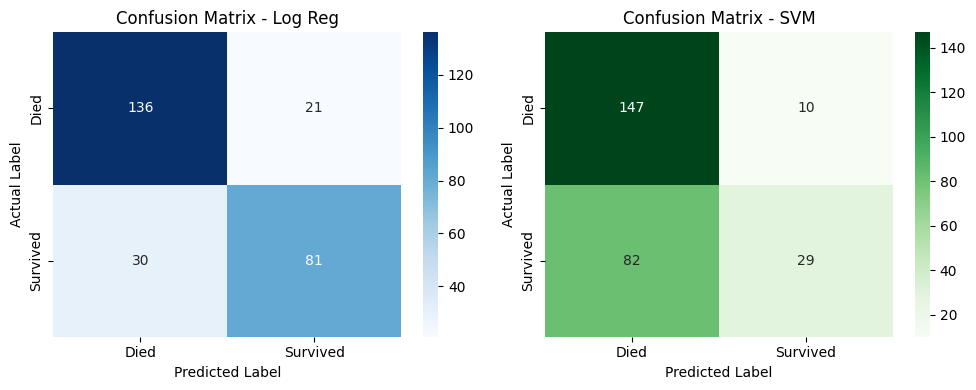

In [8]:
# setting up a 1x2 grid for the two confusion matrices
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# calculating the confusion matrix for logistic regression
cm_log = confusion_matrix(y_test, y_pred_log)
# plotting the log reg heatmap
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=ax[0], xticklabels=['Died', 'Survived'], yticklabels=['Died', 'Survived'])
ax[0].set_title('Confusion Matrix - Log Reg')
ax[0].set_ylabel('Actual Label')
ax[0].set_xlabel('Predicted Label')

# calculating the confusion matrix for svm
cm_svm = confusion_matrix(y_test, y_pred_svm)
# plotting the svm heatmap
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', ax=ax[1], xticklabels=['Died', 'Survived'], yticklabels=['Died', 'Survived'])
ax[1].set_title('Confusion Matrix - SVM')
ax[1].set_ylabel('Actual Label')
ax[1].set_xlabel('Predicted Label')

# making sure the plots don't overlap
plt.tight_layout()
# displaying the plot
plt.show()

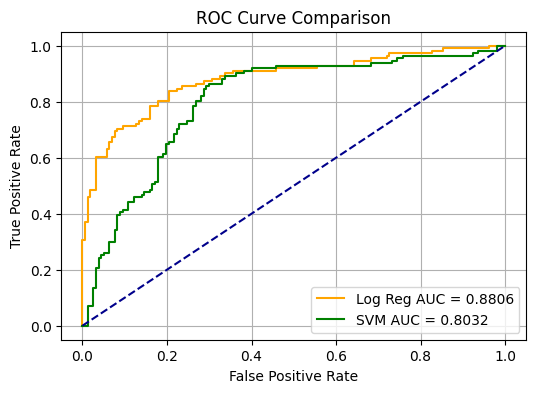

In [9]:
# calculating false positive rate, true positive rate, and auc for log reg
fpr_log, tpr_log, thresholds_log = roc_curve(y_test, y_pred_prob_log)
roc_auc_log = roc_auc_score(y_test, y_pred_prob_log)

# calculating the same metrics for svm
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_pred_prob_svm)
roc_auc_svm = roc_auc_score(y_test, y_pred_prob_svm)

# setting up the figure
plt.figure(figsize=(6, 4))
# plotting log reg roc curve
plt.plot(fpr_log, tpr_log, color='orange', label=f'Log Reg AUC = {roc_auc_log:.4f}')
# plotting svm roc curve
plt.plot(fpr_svm, tpr_svm, color='green', label=f'SVM AUC = {roc_auc_svm:.4f}')
# plotting the random guess diagonal line
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')

# adding labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
# displaying the plot
plt.show()

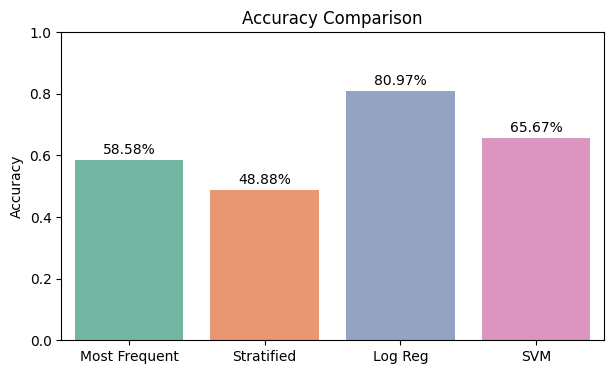

In [10]:
# creating lists of model names and their accuracies
models = ['Most Frequent', 'Stratified', 'Log Reg', 'SVM']
accuracies = [acc_freq, acc_strat, acc_log, acc_svm]

# setting up the figure size
plt.figure(figsize=(7, 4))
# plotting the bar chart
ax = sns.barplot(x=models, y=accuracies, palette='Set2')
# setting the y axis limit to 1 (100 percent)
plt.ylim(0, 1.0)
plt.title('Accuracy Comparison')
plt.ylabel('Accuracy')

# running a loop to add the percentage text on top of each bar
for i, v in enumerate(accuracies):
    ax.text(i, v + 0.02, f"{v:.2%}", ha='center')

# displaying the plot
plt.show()

**8. Observations & Conclusion**

*   **Baseline vs. ML Models:** Our most-frequent baseline gave us an accuracy of about 58.5%. The Logistic Regression model easily beat this with an accuracy of 80.97%, proving that our dataset features are actually useful for prediction.
*   **Logistic Regression Performance:** This model performed the best overall. Looking at the confusion matrix, it has a solid balance of true negatives (136) and true positives (81). The F1 score is healthy (0.76), and the ROC curve shows strong discrimination with an AUC of 0.88.
*   **SVM Performance:** The SVM model did not perform well, getting only 65.67% accuracy. If you look at its confusion matrix, it has a massive amount of false negatives (82) and only found 29 true positives. This gives it a terrible recall score of 0.26, meaning the model basically just guessed "died" for almost everybody.
*   **Why did SVM fail?** The big difference in performance comes down to feature scaling. I didn't scale numerical features (like `Fare` and `Age`) before training. Since SVM relies heavily on calculating geometric distances to find a boundary, the larger unscaled numbers completely dominated the model and threw it off. Logistic regression isn't nearly as sensitive to unscaled data, which is why it worked fine. This perfectly demonstrates why we *must* use something like `StandardScaler` before running distance-based algorithms.